In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string # Used for handling punctuation characters like .,!?;:
import nltk # Natural Language Toolkit (NLP library)
from nltk.corpus import stopwords # Provides a list of common words (e.g., "the", "is", "and") that are usually removed during text preprocessing.
from wordcloud import WordCloud # Creates a word cloud to visualize the most frequent words in text.
nltk.download('stopwords') # Downloads the NLTK stopwords dataset (only needed once).

import tensorflow as tf # TensorFlow library used for building and training deep learning models.

from tensorflow.keras.preprocessing.text import Tokenizer # Converts text into numerical sequences so neural networks can process them.

from tensorflow.keras.preprocessing.sequence import pad_sequences # Makes all text sequences the same length by adding/removing values.

from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau # Reduces the learning rate when model performance stops improving, helping the model converge more effectively.

import warnings # Used to suppress unnecessary warning messages, keeping the output cleaner.

warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LOAD DATASETS

In [ ]:
data = pd.read_csv('/content/spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [ ]:
data.shape

(5171, 4)

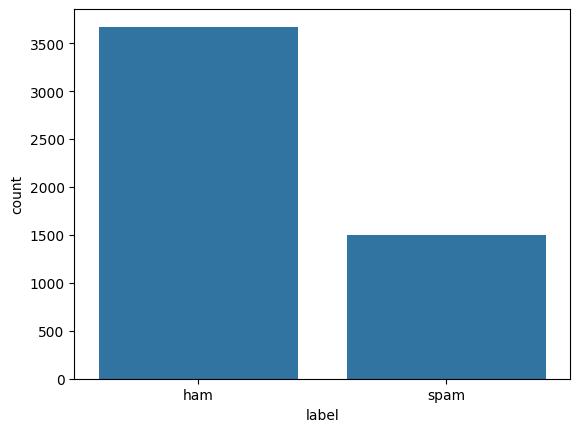

In [ ]:
sns.countplot(x='label', data=data)
plt.show()

Balance the Dataset

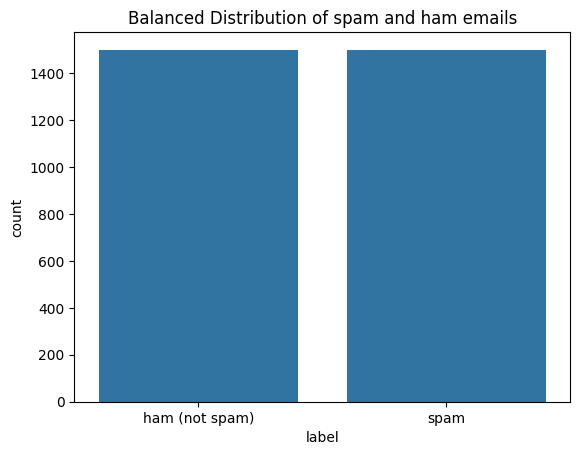

In [ ]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

#Downsample ham emails to match the number of spam emails
ham_msg_downsampled = ham_msg.sample(n=len(spam_msg), random_state=42)

#Combine the balanced datasets
balanced_data = pd.concat([ham_msg_downsampled, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of spam and ham emails")
plt.xticks(ticks=[0, 1], labels=['ham (not spam)', 'spam'])
plt.show()

**Clean the Text**

In [ ]:
balanced_data['text'] = balanced_data['text'].str.replace('subject', '')
balanced_data.head()



,Unnamed: 0,label,text,label_num
0,3444,ham,Subject: conoco - big cowboy\r\ndarren :\r\ni ...,0
1,2982,ham,Subject: feb 01 prod : sale to teco gas proces...,0
2,2711,ham,Subject: california energy crisis\r\ncaliforni...,0
3,3116,ham,Subject: re : nom / actual volume for april 23...,0
4,1314,ham,Subject: eastrans nomination changes effective...,0


In [ ]:
punctuations_list = string.punctuation
def remove_punctuations(text):
  temp = str.maketrans('', '', punctuations_list)
  return text.translate(temp)

balanced_data['text']= balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject conoco big cowboy\r\ndarren \r\ni m ...,0
1,2982,ham,Subject feb 01 prod sale to teco gas processi...,0
2,2711,ham,Subject california energy crisis\r\ncalifornia...,0
3,3116,ham,Subject re nom actual volume for april 23 rd...,0
4,1314,ham,Subject eastrans nomination changes effective ...,0


**remove the stop words**

In [ ]:
def remove_stopwords(text):
  stop_words = stopwords.words('english')

  imp_words = []

  #storing the important words
  for word in str(text).split():
    word = word.lower()
    if word not in stop_words:
      imp_words.append(word)

  output = " ".join(imp_words)

  return output

  balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
  balanced_data.head()

**Visualization Word Cloud**

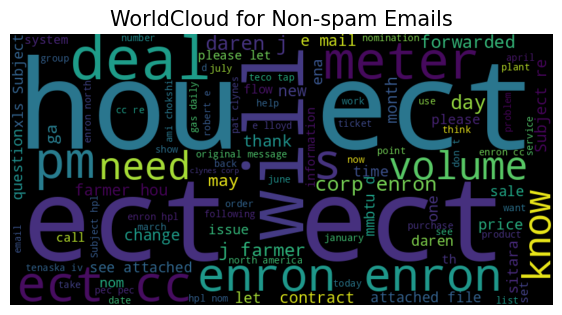

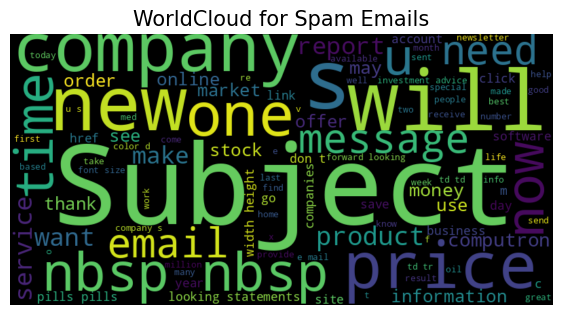

In [ ]:
def plot_word_cloud(data, type):
  email_corpus = " ".join(data['text'])
  wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
  plt.figure(figsize=(7, 7))
  plt.imshow(wc, interpolation='bilinear')
  plt.title(f'WorldCloud for {type} Emails', fontsize=15)
  plt.axis('off')
  plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], type='Non-spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], type='Spam')

**Tokeninzation and Padding**

In [ ]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100 #Maximum sequence Length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)


**Define the model**

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # output layer
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train the model**

In [ ]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    epochs=20,
    validation_data=(test_sequences, test_Y),
    batch_size=32,
    callbacks=[es, lr])

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5780 - loss: 0.6886 - val_accuracy: 0.6600 - val_loss: 0.6674 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8928 - loss: 0.3402 - val_accuracy: 0.9250 - val_loss: 0.2402 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9279 - loss: 0.2554 - val_accuracy: 0.9300 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.9358 - loss: 0.2350 - val_accuracy: 0.9317 - val_loss: 0.2454 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.8941 - loss: 0.3167 - val_accuracy: 0.8117 - val_loss: 0.4470 - learning_rate: 5.0000e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8361 - loss: 0.3899 - val_accuracy: 0.8500 - val_loss: 0.3726 - learning_rate: 5.0000e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.8678 - loss: 0.3326 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9317 - loss: 0.2454
Test Loss: 0.24543096125125885, Test Accuracy: 0.9316666722297668


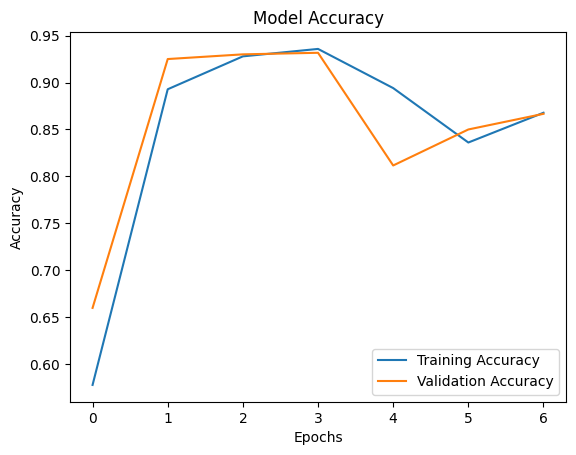

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.legend()
plt.show()